In [1]:
import pandas as pd
import numpy as np

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rakeshrau/social-network-ads")

print("Path to dataset files:", path)

100%|██████████| 3.27k/3.27k [00:00<00:00, 8.70MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rakeshrau/social-network-ads/versions/1


In [47]:
df = pd.read_csv(path + "/Social_Network_Ads.csv")
df.head()


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [49]:
model = Sequential()

In [50]:
model.add(Dense(128, activation='relu', input_shape=(2,)))
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model.compile(optimizer = "adam",loss="binary_crossentropy",metrics=["accuracy"])

In [19]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [51]:
x = df.iloc[:,2:4]

In [52]:
y = df.iloc[:,-1]

In [53]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
history = model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6156 - loss: 1731.7262 - val_accuracy: 0.3500 - val_loss: 635.5738
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4281 - loss: 545.9261 - val_accuracy: 0.6500 - val_loss: 242.7000
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4281 - loss: 199.2688 - val_accuracy: 0.6500 - val_loss: 76.1372
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4906 - loss: 132.0990 - val_accuracy: 0.6500 - val_loss: 13.7699
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5531 - loss: 60.7498 - val_accuracy: 0.6500 - val_loss: 109.0618
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5094 - loss: 98.3974 - val_accuracy: 0.6500 - val_loss: 202.1975
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4906 - loss: 166.5606 - val_accuracy: 0.6500 - val_loss: 21.3508
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5219 - loss: 71.6

When the scale of input variables is very different our validation accuracy will keep on oscillating here between 0.35 to 0.65 and is never converging.

If we recall the concept of backpropogation where we mathematically computed all the gradients with respect to the parameters and we could see the appearance of input values in it , which clearly shows the dependence of gradients on the input values. Now, when we are updating the weights the feature with larger scale dominates a lot and updates the weights with a greater differnece and hence changing the decision boundary with a huge margin, the accuracy keeps on oscillating back and forth and never converges

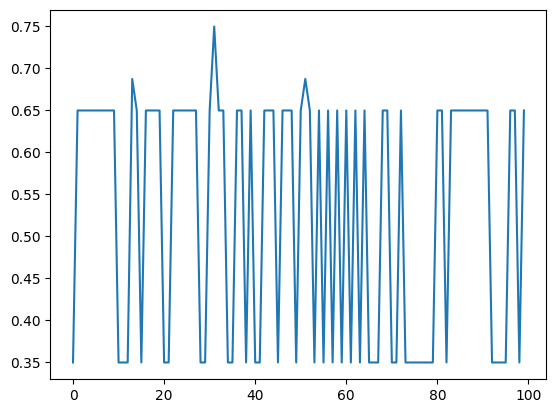

In [30]:
import matplotlib.pyplot as plt
plt.plot(history.history["val_accuracy"])

## Now normalising the data

In [31]:
from sklearn.preprocessing import MinMaxScaler

In [32]:
m = MinMaxScaler()

In [34]:
x_train_scaled = m.fit_transform(x_train)

In [35]:
x_test_scaled = m.transform(x_test)

In [66]:
df["EstimatedSalary"].max()

150000

<Axes: >

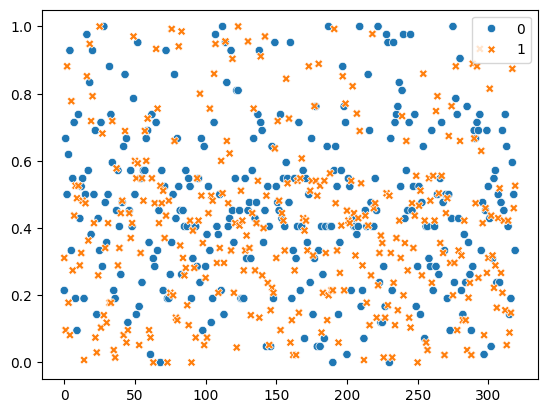

In [64]:
import seaborn as sns
sns.scatterplot(x_train_scaled)

In [36]:
history_scaled = model.fit(x_train_scaled,y_train,validation_data=(x_test_scaled,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6406 - loss: 0.6775 - val_accuracy: 0.6500 - val_loss: 0.6431
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6406 - loss: 0.6522 - val_accuracy: 0.6500 - val_loss: 0.6185
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6406 - loss: 0.6319 - val_accuracy: 0.6500 - val_loss: 0.5982
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6594 - loss: 0.6174 - val_accuracy: 0.7125 - val_loss: 0.5820
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7250 - loss: 0.6065 - val_accuracy: 0.8125 - val_loss: 0.5659
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7344 - loss: 0.5930 - val_accuracy: 0.8250 - val_loss: 0.5489
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7563 - loss: 0.5796 - val_accuracy: 0.8375 - val_loss: 0.5339
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7594 - loss: 0.5673 - val_accuracy: 0.8625 - 

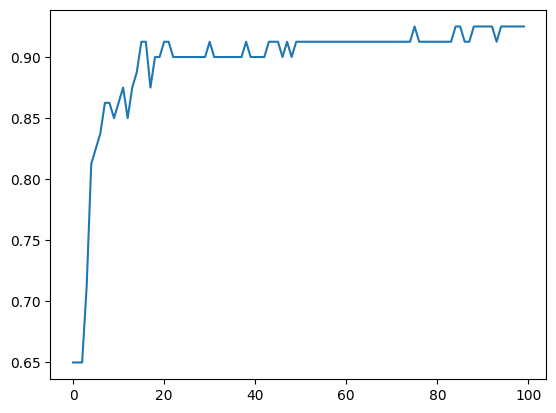

In [37]:
plt.plot(history_scaled.history["val_accuracy"])

## standardiztion tech

In [38]:
from sklearn.preprocessing import StandardScaler

In [54]:
s = StandardScaler()

In [55]:
x_train_1 = s.fit_transform(x_train)

In [56]:
x_test_1 = s.transform(x_test)

<Axes: >

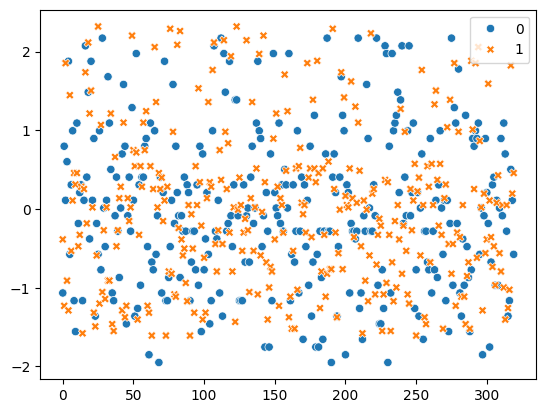

In [65]:
sns.scatterplot(x_train_1)

In [60]:
history_2 = model.fit(x_train_1,y_train,validation_data=(x_test_1,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4750 - loss: 0.6909 - val_accuracy: 0.8500 - val_loss: 0.6230
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7344 - loss: 0.6304 - val_accuracy: 0.8875 - val_loss: 0.5579
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7937 - loss: 0.5827 - val_accuracy: 0.9125 - val_loss: 0.5039
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8156 - loss: 0.5441 - val_accuracy: 0.9125 - val_loss: 0.4594
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8281 - loss: 0.5100 - val_accuracy: 0.9125 - val_loss: 0.4236
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8375 - loss: 0.4799 - val_accuracy: 0.9000 - val_loss: 0.3926
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8313 - loss: 0.4567 - val_accuracy: 0.8875 - val_loss: 0.3645
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8406 - loss: 0.4341 - val_accuracy: 0.9000 - 

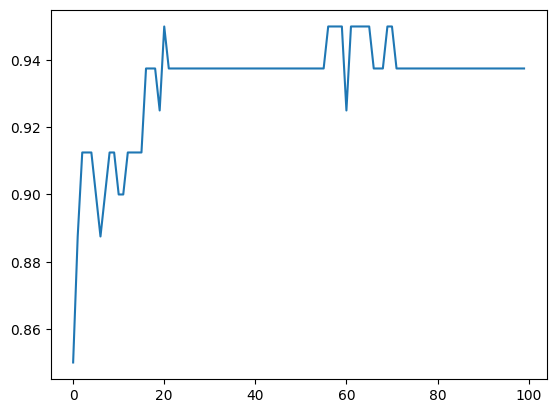

In [61]:
plt.plot(history_2.history["val_accuracy"])

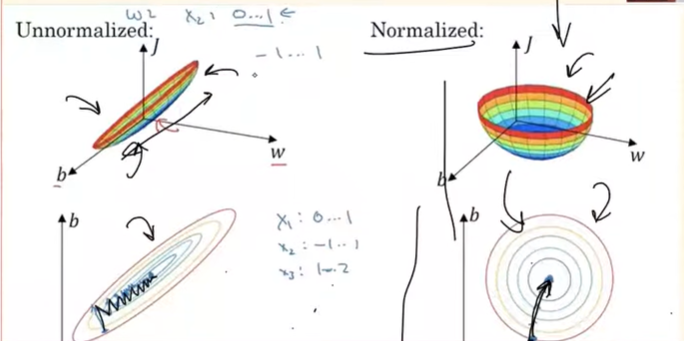

1. if min and max value of the input feature are known, for eg CGPA then we use min max scaler or data has outliers ow standardization. For eg. salary we dont know max/min value could be anything.
2. If close to normal dist standardize it.



Let's check on this data

In [62]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


we have fit the model on X = Age and Estimated salary for both we dont know the max and min value so we shall
use STANDARDIZATION technique on the given data. However, both the techniques are giving same results over here only.